#**CHAPTER 1.CONTROLLED GENERATION UNDER GOVERNANCE**
---

##REFERENCE

https://chatgpt.com/share/699a1ad1-bf10-8012-abba-81a5a9ce846b


##0.CONTEXT

**Board Briefing Narrative (Chapter 1 Notebook: Prompt as Contract) — What We Are Doing, How the Pipeline Works, What We Got, Why It Matters**

You are not being asked to “trust an AI.” You are being asked to review a **controlled generation pipeline** that treats a prompt as a **contract**: a specification that defines **scope**, **inputs**, **constraints**, **deliverable format**, and **stop rules**. In finance, the risk is not that a model is “wrong” in an abstract sense; the risk is that a fluent output is **mistakenly treated as evidence**. This notebook’s purpose is to replace that failure mode with a process that is **reviewable, auditable, and fail-closed** into human oversight.

At a high level, the notebook runs the same synthetic credit-style memo request twice:

- **v1 (naïve prompt):** “Write a credit memo from the packet.” This is what many teams do today: short instruction, high ambiguity, no enforcement of output structure.
- **v2 (contract prompt):** The same task, but converted into an explicit contract:
  - **Role** (who is speaking and for whom),
  - **Objective and non-goals** (what is in-scope vs explicitly out-of-scope),
  - **Input boundary** (the packet is the only allowed evidence),
  - **Refusal rules** (missing items must be declared, not invented),
  - **Output schema contract** (machine-checkable JSON only, required keys).

The board-relevant claim is simple: **we are not optimizing “writing quality.”** We are engineering **defensible output production**, where we can prove:
1) what inputs were allowed,  
2) what constraints were applied,  
3) what format was required,  
4) whether the output passed controls, and  
5) whether it should be escalated to **HUMAN_REVIEW**.

**Why this matters in finance**

Finance decision workflows are “artifact-first.” A committee does not approve a loan, investment, or strategy because a narrative sounds confident. They approve because the narrative can be traced to data, assumptions are explicit, and gaps are identified for diligence. LLMs can accelerate drafting, but they also introduce a specific governance hazard: **invented specificity**. The model will produce plausible detail even when the packet does not contain it. In a board environment, that is an unacceptable failure mode unless we have controls that reliably catch it.

This notebook introduces three institutional-grade controls:

**Gate A: Schema validity**  
If the model does not produce the required structured output, we treat it as a control failure. That is not “picky formatting.” It is the foundation for automation, review, and audit. No schema means no deterministic checks, which means we are back to humans eyeballing a fluent paragraph.

**Gate B: Facts vs assumptions separation**  
The output must explicitly split:
- **facts_provided** (statements grounded in the packet),
- **assumptions_introduced** (inferences or placeholders),
- **open_items / questions_to_verify** (items requiring diligence),
and it must carry **verification_status = "Not verified"**. This is the minimum viable truthfulness posture for governed drafting.

**Gate C: Boundary compliance**  
The output must not “reach outside the room.” If it references external sources, market benchmarks, ratings, or anything not contained in the packet, it is flagged as a boundary violation. In production, boundary compliance is what prevents the system from silently importing unapproved data or fabricating comparables.

**What the pipeline actually does (mechanism, not marketing)**

The notebook is built as a deterministic pipeline that emits an evidence bundle every run:

1) It sets deterministic controls (random seed, hash seed) and creates output folders.
2) It defines **schemas** (JSON Schema) that describe what “valid output” means.
3) It generates a synthetic finance micro-case (a bounded packet). This matters: we can test governance without leaking confidential data.
4) It calls Claude (the same model consistently) through a wrapper that logs:
   - prompt hash, prompt id/version, redacted prompt text,
   - response hash,
   - validation outcomes.
5) It builds **two prompt versions**: v1 and v2.
6) It runs both prompts.
7) It validates both outputs against Gate A/B/C.
8) It writes a final report that compares v1 vs v2 deterministically and assigns a decision: **OK** or **HUMAN_REVIEW**.
9) It writes a prompt trace describing why v2 exists and what constraints were added.
10) It packages everything into a zip for distribution and oversight.

This is the key conceptual shift: the notebook makes prompts **first-class governed artifacts**, not ad hoc text in someone’s clipboard.

**Interpreting the results you are seeing (including failures)**

Your screenshot shows that **Gate A is failing** for both v1 and v2: “Output was not valid JSON.” That is not a minor bug; it is a governance outcome. The notebook is behaving correctly in one important respect: it is **not pretending success**. It is failing closed and escalating. In finance governance terms, we learned something valuable: **a contract prompt alone is not sufficient unless we also harden parsing and enforce strict JSON-only behavior reliably.**

In other words:
- The pipeline’s control logic is correct (it detects failure and escalates).
- The operational reliability needs improvement (we must reduce schema failures).

This is precisely why the notebook is designed to generate artifacts: the failure is measurable, repeatable, and fixable. Without controls, the same failure would be invisible—just a nice memo that might contain invented facts.

**Why v2 still matters even when Gate A fails**

Even with schema failure, v2 is still the right architecture. It explicitly encodes:
- the allowed evidence boundary,
- refusal rules,
- output contract,
- and a structure that a reviewer can reason about.

But in real systems, you need **both**:
- a contract prompt (good specification),
- and robust output handling (parsing, extraction, repair, or re-ask).

This notebook gives you the skeleton of the governance stack; we now harden the “last mile” so the system produces machine-checkable outputs at high reliability.

**Relevance to committee workflows**

Once hardened, this pattern supports real committee use:
- Analysts provide a bounded packet (documents, numbers, terms).
- The model drafts a structured memo with explicit uncertainty.
- Gates verify schema validity, boundary compliance, and disclosure posture.
- If controls pass, the draft can be reviewed efficiently.
- If controls fail, the system escalates to human review with a risk log.

This is not automation to replace analysts. It is automation to **standardize discipline**: consistent structure, consistent disclosure, consistent audit trail, consistent escalation.

**What the notebook can do today**

- Demonstrate that “prompting” can be governed like a controlled process.
- Produce audit artifacts: manifests, prompt logs, prompt trace, risk log, final report.
- Enforce a fail-closed policy: control failures do not silently pass.
- Compare naïve prompts vs contract prompts under the same bounded packet.

**What it cannot do yet**

- It cannot verify truth externally. It is not a data connector or a fact-checker.
- It cannot guarantee schema compliance without additional hardening (robust extraction/repair loops).
- It cannot claim improved credit accuracy or better decisions; it produces drafts under governance.
- It does not yet model multi-document provenance, approvals, or sign-off workflows.

The board takeaway: this notebook is a **governance prototype** for controlled drafting. It proves that we can wrap an LLM with institutional controls and produce reviewable artifacts. It does not claim that the LLM “knows” more. It claims that the workflow is **more defensible**.

**Why this chapter belongs at the beginning of the book**

Prompt engineering is the first control surface. Before agents, before long context, before multimodal, an institution must master how to:
- state the task,
- bound the evidence,
- define what counts as valid output,
- and enforce escalation when the model deviates.

This notebook is the “AI 101” that most teams skip—and then pay for later in operational risk.

**Verification status**

All outputs are explicitly **Not verified**. That is the correct posture for committee-facing drafts unless and until a separate verification workflow is implemented.

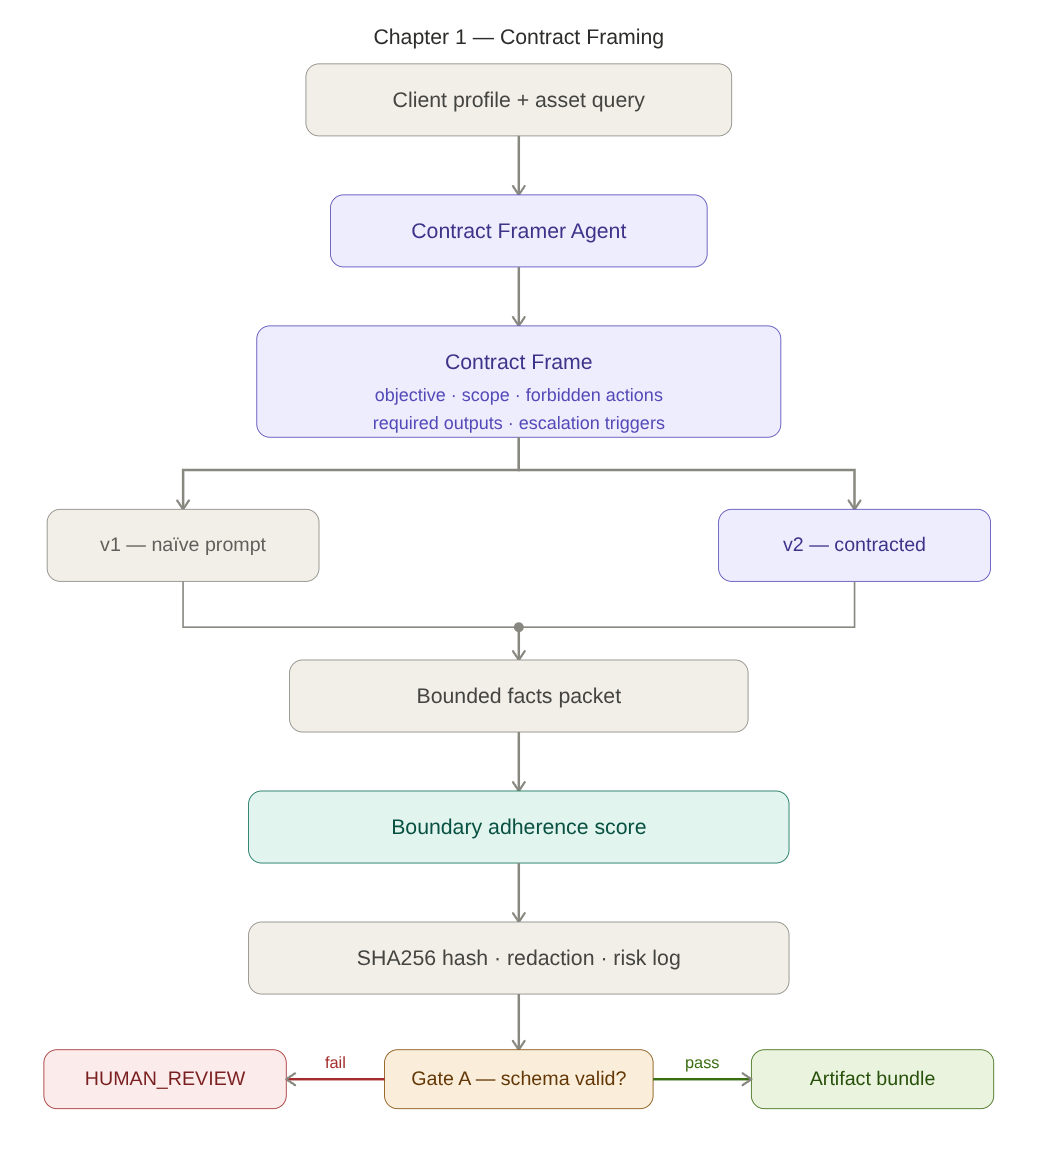

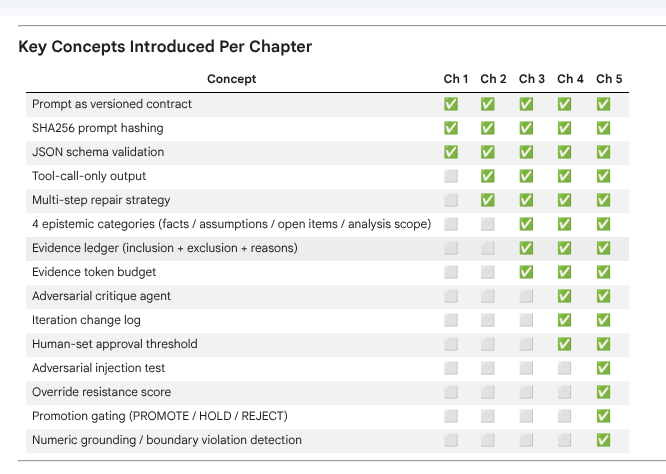

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 — Install, Imports, Determinism, and Directory Setup (Pedagogical Explanation)**

Cell 1 establishes the operational foundation of the notebook. In a board-facing workflow, we treat “the environment” as part of the control surface, because subtle environment differences (library versions, randomization behavior, filesystem assumptions) can change outcomes. This cell therefore does four essential things.

First, it installs the minimal dependencies required for the notebook to run end-to-end: the Anthropic client library for model calls and a schema validator for output controls. This is not convenience; it is governance. If the notebook does not run deterministically with a known dependency set, you cannot reproduce the evidence bundle later.

Second, it imports the standard libraries used throughout the pipeline: hashing, JSON I/O, random seed control, timestamps, and file paths. The point is to avoid hidden dependencies and to keep the notebook production-clean.

Third, it sets determinism controls. The notebook pins **PYTHONHASHSEED** and seeds the random generator. In an LLM workflow, we cannot make the model itself fully deterministic (sampling exists), but we can make the surrounding pipeline deterministic: synthetic data generation, run identifiers, and evaluation logic. This is a governance requirement because we want to distinguish “model variance” from “pipeline variance.” If the pipeline is stable, any differences are attributable to the model call and its configuration, which we log.

Fourth, it creates a structured output directory layout: **artifacts/** for governance evidence and **deliverables/** for packaging. This anticipates independent review. A reviewer should not hunt through the notebook output to understand what happened. They should find a consistent artifact structure every run.

The cell prints minimal diagnostics: paths and current UTC timestamp. That printout is not a report; it is a run sanity check. Later cells produce the formal run manifest and final report. The role of Cell 1 is simply to guarantee that the notebook is runnable, repeatable, and has a stable place to write evidence.

In [ ]:
# Cell 1 — Install + imports + deterministic settings + directory setup
!pip -q install anthropic==0.40.0 jsonschema==4.23.0

import os, json, re, hashlib, random, zipfile, pathlib, datetime, platform, sys, textwrap
from typing import Any, Dict, List, Tuple, Optional

os.environ["PYTHONHASHSEED"] = "0"
random.seed(7)

BASE_DIR = pathlib.Path(".").resolve()
ARTIFACTS_DIR = BASE_DIR / "artifacts"
DELIVERABLES_DIR = BASE_DIR / "deliverables"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
DELIVERABLES_DIR.mkdir(parents=True, exist_ok=True)

UTC_NOW = lambda: datetime.datetime.now(datetime.timezone.utc).isoformat()

print("Ready.")
print("Base:", str(BASE_DIR))
print("Artifacts:", str(ARTIFACTS_DIR))
print("Deliverables:", str(DELIVERABLES_DIR))
print("UTC:", UTC_NOW())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.5/199.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 10.8 MB/s eta 0:00:00
Ready.
Base: /content
Artifacts: /content/artifacts
Deliverables: /content/deliverables
UTC: 2026-04-03T18:46:56.352800+00:00


##2.CONFIGURATION

###2.1.OVERVIEW

**Cell 2 — Config, Schemas, and Governance Helpers (Pedagogical Explanation)**

Cell 2 defines the governance contract that turns “model output” into “reviewable output.” It does this by encoding rules into code: schemas, hashing helpers, redaction, and strict validation functions.

The **CONFIG** object is where we pin the operating parameters: model name, temperature, token limit, and notebook identity. This configuration is later written into **run_manifest.json** so the run is reproducible and auditable. In a finance environment, “what model and settings produced this memo” is a material fact for oversight.

Next, Cell 2 defines the **output schema**. This is critical: the deliverable is not arbitrary prose; it is a structured object with mandatory keys: facts, assumptions, open items, analysis, draft output, and verification status. By requiring these fields, we force a disclosure posture: the model must distinguish what was provided from what was inferred, and it must explicitly declare what remains unknown.

A separate schema governs **final_report.json**, which is the notebook’s committee-facing artifact. This final report includes both v1 and v2 outputs, a deterministic differences summary, gate outcomes, and the final decision (OK vs HUMAN_REVIEW). Encoding this schema prevents “report drift” across versions of the notebook.

Cell 2 also defines the helper functions that make auditability real:
- **sha256_text** and **sha256_json** produce stable identifiers for prompts and outputs.
- **write_json** and **append_jsonl** guarantee consistent artifact writing.
- **redact_text** prevents sensitive data from being logged, which matters in regulated workflows.
- **validate_schema** enforces strict output validity.

The philosophy is simple: a governed system does not rely on “good behavior.” It relies on enforceable contracts. Cell 2 is where those contracts are defined and where the mechanisms to enforce them are implemented.

###2.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 2 — Config + schemas + helpers (hashing, redaction, JSON writing, validation)
from jsonschema import validate as js_validate, Draft202012Validator

CONFIG = {
    "project": "Prompt Engineering for Finance — Controlled Generation Under Governance",
    "notebook": "Notebook 1 — Prompt as Contract",
    "model": "claude-haiku-4-5-20251001",
    "temperature": 0.2,
    "max_tokens": 2500,  # raised from 1200 — analysis alone was exhausting the budget
    "max_iterations": 2,
}


OUTPUT_SCHEMA_ID = "memo_v1_contract_schema_v1"
OUTPUT_SCHEMA = {
    "$schema": "https://json-schema.org/draft/2020-12/schema",
    "$id": OUTPUT_SCHEMA_ID,
    "type": "object",
    "additionalProperties": False,
    "required": [
        "facts_provided",
        "assumptions_introduced",
        "open_items",
        "analysis",
        "draft_output",
        "verification_status",
    ],
    "properties": {
        "facts_provided": {"type": "array", "items": {"type": "string"}},
        "assumptions_introduced": {"type": "array", "items": {"type": "string"}},
        "open_items": {"type": "array", "items": {"type": "string"}},
        "analysis": {"type": "string"},
        "draft_output": {"type": "string"},
        "verification_status": {"type": "string", "enum": ["Not verified"]},
    },
}

FINAL_REPORT_SCHEMA_ID = "final_report_schema_v1"
FINAL_REPORT_SCHEMA = {
    "$schema": "https://json-schema.org/draft/2020-12/schema",
    "$id": FINAL_REPORT_SCHEMA_ID,
    "type": "object",
    "additionalProperties": False,
    "required": [
        "run_id",
        "timestamp_utc",
        "config",
        "case_packet",
        "baseline_output",
        "contract_output",
        "differences_summary",
        "open_items",
        "verification_status",
        "decision",
        "gates",
    ],
    "properties": {
        "run_id": {"type": "string"},
        "timestamp_utc": {"type": "string"},
        "config": {"type": "object"},
        "case_packet": {"type": "object"},
        "baseline_output": {"type": ["object", "string", "null"]},
        "contract_output": {"type": ["object", "string", "null"]},
        "differences_summary": {"type": "object"},
        "open_items": {"type": "array", "items": {"type": "string"}},
        "verification_status": {"type": "string", "enum": ["Not verified"]},
        "decision": {"type": "string", "enum": ["OK", "HUMAN_REVIEW"]},
        "gates": {"type": "object"},
    },
}

def sha256_text(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

def sha256_json(obj: Any) -> str:
    canonical = json.dumps(obj, sort_keys=True, separators=(",", ":"), ensure_ascii=False)
    return sha256_text(canonical)

def write_json(path: pathlib.Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")
    tmp.replace(path)

def append_jsonl(path: pathlib.Path, obj: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False) + "\n")

_REDACT_PATTERNS = [
    (re.compile(r"(?i)\b(sk-[a-z0-9]{10,})\b"), "<REDACTED_KEY>"),
    (re.compile(r"(?i)\b([A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,})\b"), "<REDACTED_EMAIL>"),
    (re.compile(r"\b\d{3}-\d{2}-\d{4}\b"), "<REDACTED_SSN>"),
    (re.compile(r"\b\d{10,16}\b"), "<REDACTED_NUMBER>"),
]

def redact_text(s: str) -> str:
    out = s
    for pat, repl in _REDACT_PATTERNS:
        out = pat.sub(repl, out)
    out = re.sub(r"\b\d+(\.\d+)?\b", "<NUM>", out)
    return out[:6000]

def validate_schema(obj: Any, schema: Dict[str, Any]) -> Tuple[bool, List[str]]:
    try:
        Draft202012Validator(schema).validate(obj)
        return True, []
    except Exception as e:
        return False, [str(e)]

def safe_json_loads(s: str) -> Tuple[Optional[Any], Optional[str]]:
    try:
        return json.loads(s), None
    except Exception as e:
        return None, str(e)

def now_run_id() -> str:
    return sha256_text(UTC_NOW() + "|" + str(random.random()))[:16]

print("Helpers ready.")

Helpers ready.


##3.SYNTHETIC CASE GENERATOR

###3.1.OVERVIEW

**Cell 3 — Deterministic Synthetic Finance Micro-Case and Input Boundary (Pedagogical Explanation)**

Cell 3 constructs the bounded packet that the model is allowed to use. This is a deliberately synthetic case because the goal of the notebook is to demonstrate governance mechanics without introducing confidentiality, data room complexity, or real-world data provenance. In a board setting, synthetic-first labs are valuable because they allow repeatable testing of controls.

The case generator uses a fixed seed to ensure the packet is deterministic. This matters because we want the same inputs each run unless deliberately changed. The packet includes borrower identity (synthetic), basic financial metrics, facility request details, terms, risks, and strengths. Most importantly, it includes an explicit **input boundary rule**: “Use ONLY the packet fields. Do NOT invent facts.”

This boundary is the heart of prompt-as-contract. Many failures in unguided LLM use occur because the model fills gaps. By explicitly defining what is allowed, we can later evaluate whether the model violated that boundary. The notebook also captures the set of boundary keys, which becomes part of the prompt components and part of the prompt trace. That means a reviewer can see exactly what the model was permitted to reference.

Cell 3 also prints the boundary keys. This is a small but important usability feature: it makes the evidence boundary visible to the analyst running the notebook. It reinforces the governance posture: “We are not doing open-ended generation; we are generating within a bounded packet.”

In later notebooks (context packing and hardening), this concept evolves into multi-document evidence selection and provenance tracking. Here, Cell 3 is intentionally simple: one packet, explicit boundary, deterministic creation. It is the controlled sandbox in which the prompt lifecycle and gates can be tested.

###3.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 3 — Synthetic finance micro-case generator (deterministic) + input boundary definition
def generate_synthetic_case(seed: int = 101) -> Dict[str, Any]:
    rnd = random.Random(seed)
    borrower = "Acme Components S.A."
    industry = "Auto parts manufacturing"
    currency = "USD"
    revenue = 48_500_000
    ebitda = 6_400_000
    total_debt = 18_000_000
    cash = 2_100_000
    interest_rate = 0.085
    term_years = 3
    purpose = "Working capital and capex for a new production line"
    collateral = "First lien on equipment; inventory pledge"
    covenants = [
        "Max net leverage 3.0x",
        "Min interest coverage 3.0x",
        "Quarterly reporting within 30 days",
    ]
    red_flags = [
        "Customer concentration: top 2 customers = 52% of revenue",
        "Recent margin compression due to input costs",
    ]
    positives = [
        "Stable order book with OEM contracts",
        "Experienced management team; 12-year operating history",
    ]
    packet = {
        "borrower_name": borrower,
        "industry": industry,
        "currency": currency,
        "financials": {
            "revenue_ttm": revenue,
            "ebitda_ttm": ebitda,
            "cash": cash,
            "total_debt": total_debt,
        },
        "facility_request": {
            "type": "Term loan",
            "amount": 10_000_000,
            "term_years": term_years,
            "pricing_assumption": f"{int(interest_rate*10000)} bps all-in (synthetic)",
            "purpose": purpose,
        },
        "credit_terms": {
            "collateral": collateral,
            "covenants": covenants,
        },
        "known_risks": red_flags,
        "known_strengths": positives,
        "input_boundary_rule": "Use ONLY the packet fields. Do NOT invent facts, sources, or market data. Missing items must be listed in open_items.",
    }
    return packet

CASE = generate_synthetic_case()
INPUT_BOUNDARY_KEYS = sorted(list(CASE.keys()))
FACTS_BOUNDARY_TEXT = json.dumps(CASE, indent=2, ensure_ascii=False)

print("Synthetic case generated.")
print("Boundary keys:", INPUT_BOUNDARY_KEYS)

Synthetic case generated.
Boundary keys: ['borrower_name', 'credit_terms', 'currency', 'facility_request', 'financials', 'industry', 'input_boundary_rule', 'known_risks', 'known_strengths']


##4.LLM CASE WRAPPER

###4.1.OVERVIEW

**Cell 4 — Anthropic Client Wrapper and Prompt Logging (Pedagogical Explanation)**

Cell 4 is where the notebook connects to the model under governance controls. The most important design decision is that the model call is wrapped by a function that logs inputs and outputs as auditable artifacts, without leaking secrets or sensitive content.

First, it reads the API key from Colab Secrets using `google.colab.userdata.get("ANTHROPIC_API_KEY")`. This is governance hygiene: keys do not appear in the notebook, the logs, or the artifacts. The key is treated as an operational secret.

Second, the cell constructs a client for Anthropic and defines the prompt log and risk log paths. The notebook writes a prompts log as JSONL because each model call is an auditable event. A reviewer should be able to reconstruct the lifecycle: which prompt version ran, what its intent was, and what it returned.

Third, it defines a **risk log** function. This is more than logging errors; it is a governance record with severity, category, control, and status. The categories include prompt-specific risks like schema failure and boundary violations. This aligns with institutional expectations: risks are named, recorded, and tied to controls.

Fourth, it defines the **anthropic_call** wrapper. This wrapper:
- builds the full prompt text (system + user),
- produces a stable prompt hash,
- redacts sensitive content for logging,
- executes the LLM call with bounded temperature and tokens,
- hashes the response,
- appends a redacted prompt log entry.

Crucially, this cell establishes that every LLM call has identity: prompt_id, version, intent, hashes, and configuration. Without this wrapper, a notebook is just a demo. With it, the notebook becomes an auditable process. This is the level of discipline required when AI is used in decision workflows that may be reviewed by audit, risk, compliance, or regulators.

###4.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 4 — LLM client wrapper (Anthropic) + prompt logging (redacted + hashes)
from google.colab import userdata

ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_API_KEY")
if not ANTHROPIC_API_KEY:
    raise RuntimeError("Missing Colab Secret: ANTHROPIC_API_KEY")

from anthropic import Anthropic

client = Anthropic(api_key=ANTHROPIC_API_KEY)

PROMPTS_LOG_PATH = ARTIFACTS_DIR / "prompts_log.jsonl"
RISK_LOG_PATH = ARTIFACTS_DIR / "risk_log.json"
PROMPT_TRACE_PATH = ARTIFACTS_DIR / "prompt_trace.json"

RISK_LOG: List[Dict[str, Any]] = []

def log_risk(severity: str, category: str, description: str, control: str, status: str = "OPEN") -> str:
    risk_id = sha256_text(f"{UTC_NOW()}|{severity}|{category}|{description}")[:12]
    entry = {
        "risk_id": risk_id,
        "timestamp_utc": UTC_NOW(),
        "severity": severity,
        "category": category,
        "description": description,
        "control": control,
        "status": status,
    }
    RISK_LOG.append(entry)
    return risk_id

def anthropic_call(prompt_bundle: Dict[str, Any]) -> Dict[str, Any]:
    system_text = prompt_bundle["prompt_components"]["system_policy"]
    user_text = prompt_bundle["prompt_components"]["user_task_spec"]
    temperature = float(prompt_bundle.get("temperature", CONFIG["temperature"]))
    max_tokens = int(prompt_bundle.get("max_tokens", CONFIG["max_tokens"]))

    raw_prompt_text = f"SYSTEM:\n{system_text}\n\nUSER:\n{user_text}"
    redacted_prompt = redact_text(raw_prompt_text)

    prompt_sha = sha256_text(raw_prompt_text)
    prompt_id = prompt_bundle["prompt_id"]
    response_text = ""
    try:
        msg = client.messages.create(
            model=CONFIG["model"],
            temperature=temperature,
            max_tokens=max_tokens,
            system=system_text,
            messages=[{"role": "user", "content": user_text}],
        )
        response_text = msg.content[0].text if msg.content else ""
    except Exception as e:
        log_risk("HIGH", "instruction_conflict", f"LLM call failed: {str(e)}", "Fail closed to HUMAN_REVIEW", "OPEN")
        response_text = ""

    response_sha = sha256_text(response_text)

    log_entry = {
        "timestamp_utc": UTC_NOW(),
        "prompt_id": prompt_id,
        "prompt_version": prompt_bundle["prompt_version"],
        "prompt_intent": prompt_bundle["prompt_intent"],
        "prompt_components": {
            "system_policy": "<REDACTED_STORED_AS_HASH_ONLY>",
            "developer_constraints": prompt_bundle["prompt_components"].get("developer_constraints", []),
            "user_task_spec": "<REDACTED_STORED_AS_REDACTED_TEXT>",
            "input_boundary": prompt_bundle["prompt_components"]["input_boundary"],
            "output_schema": prompt_bundle["prompt_components"]["output_schema_id"],
            "stop_rules": prompt_bundle["prompt_components"]["stop_rules"],
        },
        "redacted_prompt_text": redacted_prompt,
        "prompt_sha256": prompt_sha,
        "response_sha256": response_sha,
        "temperature": temperature,
        "max_tokens": max_tokens,
    }
    append_jsonl(PROMPTS_LOG_PATH, log_entry)

    return {
        "raw_response_text": response_text,
        "prompt_sha256": prompt_sha,
        "response_sha256": response_sha,
        "redacted_prompt_text": redacted_prompt,
    }

print("Anthropic client ready.")

Anthropic client ready.


In [ ]:
import json, re
from typing import Any, Dict, Tuple, Optional, List

def strip_code_fences(text: str) -> str:
    t = (text or "").strip()
    # Remove common fenced blocks
    t = re.sub(r"^\s*```(?:json)?\s*", "", t, flags=re.IGNORECASE)
    t = re.sub(r"\s*```\s*$", "", t)
    return t.strip()

def find_first_json_object(text: str) -> Optional[str]:
    """
    Returns the first balanced {...} JSON object substring if found, else None.
    Works even if there is leading/trailing text.
    """
    t = strip_code_fences(text)
    # Fast path: starts with { and ends with }
    if t.startswith("{") and t.endswith("}"):
        return t

    # Scan for first '{' then balance braces while respecting strings
    start = t.find("{")
    if start == -1:
        return None

    in_str = False
    esc = False
    depth = 0
    for i in range(start, len(t)):
        ch = t[i]
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
        else:
            if ch == '"':
                in_str = True
            elif ch == "{":
                depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0:
                    return t[start:i+1]
    return None

def parse_json_lenient(raw_text: str) -> Tuple[Optional[Any], Optional[str], Optional[str]]:
    """
    Returns: (parsed_obj, error, extracted_json_text)
    """
    t = strip_code_fences(raw_text)
    extracted = find_first_json_object(t)
    if extracted is None:
        return None, "No JSON object found in output.", None
    try:
        return json.loads(extracted), None, extracted
    except Exception as e:
        return None, f"JSON parse error after extraction: {str(e)}", extracted

def build_repair_prompt(invalid_text: str, schema: Dict[str, Any]) -> str:
    return (
        "You must output ONLY valid JSON. No markdown. No explanation. No code fences.\n"
        "If you cannot comply, output exactly: {\"error\":\"HUMAN_REVIEW\"}\n\n"
        "Your prior output was invalid. Repair it to match this JSON schema exactly.\n\n"
        "SCHEMA:\n"
        f"{json.dumps(schema, ensure_ascii=False)}\n\n"
        "INVALID OUTPUT TO REPAIR:\n"
        f"{invalid_text}\n"
    )

def run_prompt_strict(prompt_bundle: Dict[str, Any], schema: Dict[str, Any], max_repair_attempts: int = 1) -> Dict[str, Any]:
    """
    Calls Claude, then parses leniently. If parsing fails, retries once with a repair prompt.
    Still fail-closed: if schema invalid => HUMAN_REVIEW.
    """
    # 1) normal call
    call_meta = anthropic_call(prompt_bundle)
    raw_text = (call_meta.get("raw_response_text") or "").strip()

    parsed, parse_err, extracted = parse_json_lenient(raw_text)
    validation_ok, validation_errors = (False, [])

    if parsed is not None:
        validation_ok, validation_errors = validate_schema(parsed, schema)

    detected_risks = []
    if parse_err is not None:
        detected_risks.append("verbosity_or_format_drift")
    if parsed is None or not validation_ok:
        detected_risks.append("schema_failure")

    # 2) repair retry (optional)
    repaired_raw = None
    if (parsed is None or not validation_ok) and max_repair_attempts > 0:
        # Log the failure
        log_risk(
            "HIGH",
            "schema_failure",
            f"Initial output parse/validation failed. parse_err={parse_err} schema_ok={validation_ok}",
            "Repair attempt with strict JSON-only prompt; if fails => HUMAN_REVIEW",
            "OPEN",
        )

        repair_bundle = dict(prompt_bundle)
        repair_bundle["prompt_version"] = prompt_bundle["prompt_version"] + "_repair"
        repair_bundle["prompt_intent"] = "repair_to_schema"
        repair_bundle["prompt_components"] = dict(prompt_bundle["prompt_components"])
        repair_bundle["prompt_components"]["user_task_spec"] = build_repair_prompt(raw_text, schema)

        repair_meta = anthropic_call(repair_bundle)
        repaired_raw = (repair_meta.get("raw_response_text") or "").strip()

        parsed2, parse_err2, extracted2 = parse_json_lenient(repaired_raw)
        if parsed2 is not None:
            validation_ok2, validation_errors2 = validate_schema(parsed2, schema)
        else:
            validation_ok2, validation_errors2 = (False, [])

        # Prefer repaired output if it validates
        if parsed2 is not None and validation_ok2:
            parsed, parse_err, extracted = parsed2, None, extracted2
            validation_ok, validation_errors = True, []
            detected_risks = [r for r in detected_risks if r != "schema_failure"]
        else:
            # Keep original failure context but record more detail
            log_risk(
                "HIGH",
                "schema_failure",
                f"Repair attempt failed. parse_err={parse_err2} schema_ok={validation_ok2} errors={validation_errors2[:1]}",
                "Fail closed to HUMAN_REVIEW",
                "OPEN",
            )

    return {
        "prompt_id": prompt_bundle["prompt_id"],
        "prompt_version": prompt_bundle["prompt_version"],
        "prompt_intent": prompt_bundle["prompt_intent"],
        "prompt_sha256": call_meta.get("prompt_sha256"),
        "response_sha256": call_meta.get("response_sha256"),
        "raw_response_text": raw_text,
        "extracted_json_text": extracted,
        "repaired_raw_response_text": repaired_raw,
        "parsed_output": parsed,
        "parse_error": parse_err,
        "schema_validation_result": {"ok": validation_ok, "errors": validation_errors},
        "detected_prompt_risks": detected_risks,
    }

print("Strict parser + repair runner installed.")

Strict parser + repair runner installed.


##5.CONTRACT PROMPT

###5.1.OVERVIEW

**Cell 5 — Prompt-as-Contract Engine (v1 vs v2) and Execution Function (Pedagogical Explanation)**

Cell 5 contains the conceptual core of Chapter 1: it operationalizes “prompt as contract” by generating two prompt versions for the same task and running them through the same model call wrapper.

The first function, **build_prompt_v1**, constructs a naïve prompt. It states the task (“write a credit memo from the packet”) but leaves critical elements implicit: what the role is, what is out-of-scope, what the refusal rules are, and what the output must look like. v1 exists as a baseline representing how many teams prompt today.

The second function, **build_prompt_v2_contract**, creates the contract prompt. It explicitly encodes:
- **Role**: who the model is pretending to be (credit analyst for committee drafting),
- **Objective**: produce a first-pass memo strictly from packet,
- **Non-goals**: ban external comparables, ratings, market stats,
- **Refusal rules**: missing details must go into open_items, not guessed,
- **Boundary**: the packet’s keys are the only allowed evidence,
- **Output contract**: return JSON only, matching the schema, no extra keys.

This is the “prompt lifecycle” idea in concrete form: v2 is not “a better prompt” by vibes; it is a new version that adds explicit constraints for governance reasons. These constraints are later recorded in the prompt trace to document why v2 exists.

Finally, Cell 5 defines a runner that:
- calls the model,
- attempts to parse the response,
- validates it against the schema,
- logs schema failures as risks.

This is why your screenshot matters: Gate A failures indicate that the model did not comply with JSON-only output. The notebook is correctly surfacing that as a control failure rather than pretending the output is acceptable. In practice, the next refinement is to harden parsing and enforce a bounded repair attempt, but Cell 5 establishes the essential architecture: prompt versions, explicit contract prompt, and schema-based governance.

###5.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 5 — Contract prompt engine (v1 naive, v2 contract) + runner
def _base_system_policy() -> str:
    return (
        "You are a finance professional assistant. "
        "You must be conservative, board-ready, and control-grade. "
        "Never fabricate facts, sources, market data, or citations. "
        "If something is missing, put it in open_items. "
        "Always set verification_status to 'Not verified'."
    )

def build_prompt_v1(case: Dict[str, Any]) -> Dict[str, Any]:
    system_policy = _base_system_policy()
    user_task = (
        "Write a short credit memo for an internal committee based on the packet below.\n\n"
        f"PACKET (bounded facts):\n{json.dumps(case, indent=2, ensure_ascii=False)}\n\n"
        "Keep it concise."
    )
    raw = system_policy + "\n\n" + user_task
    prompt_id = sha256_text(raw)[:16]
    return {
        "prompt_id": prompt_id,
        "prompt_version": "v1",
        "prompt_intent": "draft",
        "temperature": CONFIG["temperature"],
        "max_tokens": CONFIG["max_tokens"],
        "prompt_components": {
            "system_policy": system_policy,
            "developer_constraints": [
                "No fabricated facts or sources",
                "Board-ready tone",
            ],
            "user_task_spec": user_task,
            "input_boundary": {"keys": INPUT_BOUNDARY_KEYS, "rule": case["input_boundary_rule"]},
            "output_schema_id": OUTPUT_SCHEMA_ID,
            "stop_rules": [
                "If uncertain, add to open_items",
                "No external data",
            ],
        },
    }

def build_prompt_v2_contract(case: Dict[str, Any], schema: Dict[str, Any]) -> Dict[str, Any]:
    system_policy = _base_system_policy()
    role = "Role: Credit analyst drafting for a bank/investment committee."
    objective = "Objective: Produce a first-pass credit summary strictly from the packet."
    non_goals = "Non-goals: Do not add market comps, ratings, external industry statistics, or unstated borrower details."
    refusal = "Refusal rules: If a requested detail is not in the packet, do not guess; record it in open_items."
    boundary = f"Input boundary keys: {', '.join(INPUT_BOUNDARY_KEYS)}. Use ONLY these fields."
    schema_contract = (
        "Output contract: Return ONLY valid JSON that matches the provided schema. "
        "Do not include any extra keys. Do not include markdown. Do not wrap in code fences."
    )
    # ← added: explicit field length caps to prevent JSON truncation
    length_rules = (
        "Output length rules (REQUIRED to prevent truncation):\n"
        "- analysis: <= 1500 characters\n"
        "- draft_output: <= 1000 characters\n"
        "- list fields (facts_provided, assumptions_introduced, open_items): short bullet strings only\n"
        "- If running long, shorten draft_output first. DO NOT truncate the JSON object."
    )
    schema_text = json.dumps(schema, ensure_ascii=False)

    user_task = (
        f"{role}\n{objective}\n{non_goals}\n{refusal}\n{boundary}\n\n"
        f"{length_rules}\n\n"
        "PACKET (bounded facts):\n"
        f"{json.dumps(case, indent=2, ensure_ascii=False)}\n\n"
        f"REQUIRED JSON SCHEMA:\n{schema_text}\n\n"
        "Now produce the JSON output. Start with {{ and end with }}."
    )
    raw = system_policy + "\n\n" + user_task
    prompt_id = sha256_text(raw)[:16]
    return {
        "prompt_id": prompt_id,
        "prompt_version": "v2",
        "prompt_intent": "draft_contract",
        "temperature": CONFIG["temperature"],
        "max_tokens": CONFIG["max_tokens"],
        "prompt_components": {
            "system_policy": system_policy,
            "developer_constraints": [
                "Prompt as contract: role/objective/non-goals/boundary/refusal/schema",
                "JSON-only output",
                "No fabricated facts or sources",
                "Field length caps: analysis<=1500, draft_output<=1000",  # ← logged in trace
            ],
            "user_task_spec": user_task,
            "input_boundary": {"keys": INPUT_BOUNDARY_KEYS, "rule": case["input_boundary_rule"]},
            "output_schema_id": OUTPUT_SCHEMA_ID,
            "stop_rules": [
                "Return JSON only",
                "No external data",
                "Missing -> open_items",
                "Do not truncate JSON object",
            ],
        },
    }

def run_prompt(prompt_bundle: Dict[str, Any]) -> Dict[str, Any]:
    call_meta = anthropic_call(prompt_bundle)
    raw_text = (call_meta.get("raw_response_text") or "").strip()

    parsed, parse_err = safe_json_loads(raw_text)
    validation_ok, validation_errors = (False, [])
    if parsed is not None:
        validation_ok, validation_errors = validate_schema(parsed, OUTPUT_SCHEMA)

    detected_risks = []
    if parse_err is not None:
        detected_risks.append("verbosity_or_format_drift")
        log_risk(
            "HIGH",
            "schema_failure",
            f"Output was not valid JSON: {parse_err}",
            "Gate A schema validity => fail closed",
            "OPEN",
        )
    elif not validation_ok:
        detected_risks.append("schema_failure")
        log_risk(
            "HIGH",
            "schema_failure",
            f"JSON failed schema validation: {validation_errors[0] if validation_errors else 'unknown'}",
            "Gate A schema validity => fail closed",
            "OPEN",
        )

    return {
        "prompt_id": prompt_bundle["prompt_id"],
        "prompt_version": prompt_bundle["prompt_version"],
        "prompt_intent": prompt_bundle["prompt_intent"],
        "prompt_sha256": call_meta.get("prompt_sha256"),
        "response_sha256": call_meta.get("response_sha256"),
        "redacted_prompt_text": call_meta.get("redacted_prompt_text"),
        "raw_response_text": raw_text,
        "parsed_output": parsed,
        "parse_error": parse_err,
        "schema_validation_result": {"ok": validation_ok, "errors": validation_errors},
        "detected_prompt_risks": detected_risks,
    }

print("Prompt engine ready.")

Prompt engine ready.


##6.GATES

###6.1.OVERVIEW

**Cell 6 — Gates, Risk Detection, and Fail-Closed Escalation (Pedagogical Explanation)**

Cell 6 translates governance policy into enforceable controls. It defines the gates that decide whether output can proceed as “reviewable” or must be escalated to **HUMAN_REVIEW**. This is the practical difference between a demo and an institutional workflow.

**Gate A (Schema validity)** checks whether the output parses and matches the schema. This is the first gate because without structured output, later checks are unreliable. If the model returns prose, Gate A fails. Importantly, this is not aesthetic; schema validity is how we make outputs machine-checkable.

**Gate B (Facts vs assumptions separation)** verifies that the output contains the required lists (facts, assumptions, open items) and the required verification status. This enforces disclosure. A model that produces a persuasive narrative without disclosing open items is dangerous in committee settings, even if the narrative is well written.

**Gate C (Boundary compliance)** checks for boundary violations—references to external sources, ratings agencies, or market data not present in the packet. In the notebook, this is implemented with conservative heuristics (marker detection). The intent is correct: detect “reaching outside the room.” Over time, this control becomes more sophisticated by mapping claims to input keys, but the gate establishes the critical discipline.

Cell 6 also centralizes the decision logic: if any gate fails, the overall decision becomes **HUMAN_REVIEW**. This is the fail-closed posture. The system does not attempt to “smooth over” failures; it escalates them with a risk log entry tied to a named control. That is exactly what we want if we are demonstrating AI use to a board: a process that is conservative and reviewable.

In your current run, Gate A failures prevent Gate B and C from evaluating because there is no valid parsed object. That is correct sequencing. The remedy is not to weaken Gate A; the remedy is to harden the system so outputs comply with the schema reliably.

###6.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 6 — Gate(s) + prompt-risk detection + escalation logic
def _extract_all_strings(obj: Any) -> str:
    if obj is None:
        return ""
    if isinstance(obj, str):
        return obj
    if isinstance(obj, list):
        return " ".join(_extract_all_strings(x) for x in obj)
    if isinstance(obj, dict):
        return " ".join(_extract_all_strings(v) for v in obj.values())
    return str(obj)

def gate_schema(result: Dict[str, Any]) -> Tuple[bool, str]:
    ok = bool(result["schema_validation_result"]["ok"])
    return ok, "Gate A schema validity"

def gate_facts_vs_assumptions(result: Dict[str, Any]) -> Tuple[bool, str]:
    out = result.get("parsed_output")
    if not isinstance(out, dict):
        return False, "Gate B facts vs assumptions separation (no parsed object)"
    for k in ["facts_provided", "assumptions_introduced", "open_items"]:
        if k not in out or not isinstance(out[k], list):
            return False, f"Gate B facts vs assumptions separation (missing/invalid {k})"
    if out.get("verification_status") != "Not verified":
        return False, "Gate B verification_status must be 'Not verified'"
    return True, "Gate B facts vs assumptions separation"

def gate_boundary_compliance(result: Dict[str, Any], case: Dict[str, Any]) -> Tuple[bool, str]:
    out = result.get("parsed_output")
    if not isinstance(out, dict):
        return False, "Gate C boundary compliance (no parsed object)"
    text_blob = _extract_all_strings(out).lower()
    forbidden_markers = ["source:", "according to", "rating agency", "bloomberg", "reuters", "moody", "s&p", "fitch"]
    if any(m in text_blob for m in forbidden_markers):
        log_risk("HIGH", "evidence_boundary_violation", "Output referenced external sources/market data markers.", "Gate C boundary compliance", "OPEN")
        return False, "Gate C boundary compliance (external sources markers)"
    packet_blob = json.dumps(case, ensure_ascii=False).lower()
    # Simple heuristic: if the model introduces a named third party not in packet, flag as potential invention.
    invented_named = False
    for token in ["wacc", "peer multiple", "industry average", "implied rating", "recent refinancing"]:
        if token in text_blob and token not in packet_blob:
            invented_named = True
    if invented_named:
        log_risk("HIGH", "assumption_leak", "Potential invented analytical facts not supported by packet.", "Gate C boundary compliance", "OPEN")
        return False, "Gate C boundary compliance (possible invented facts)"
    return True, "Gate C boundary compliance"

def evaluate_gates(result: Dict[str, Any], case: Dict[str, Any]) -> Dict[str, Any]:
    gates = {}
    ok_a, name_a = gate_schema(result)
    gates["gate_a_schema_validity"] = {"ok": ok_a, "name": name_a}

    ok_b, name_b = gate_facts_vs_assumptions(result)
    gates["gate_b_facts_vs_assumptions"] = {"ok": ok_b, "name": name_b}

    ok_c, name_c = gate_boundary_compliance(result, case)
    gates["gate_c_boundary_compliance"] = {"ok": ok_c, "name": name_c}

    overall_ok = ok_a and ok_b and ok_c
    decision = "OK" if overall_ok else "HUMAN_REVIEW"
    return {"decision": decision, "gates": gates}

print("Gates ready.")

Gates ready.


##7.PROMPT TRACE

###7.1.OVERVIEW

**Cell 7 — Prompt Trace Builder (Lifecycle Documentation) (Pedagogical Explanation)**

Cell 7 produces the artifact that makes this book different from typical “prompting guides”: it records the **prompt lifecycle** as a structured trace. In this notebook, the trace is a simple sequence with exactly two nodes: v1 → v2.

Each node in the trace contains:
- prompt id and version,
- prompt intent,
- inputs used (boundary keys),
- constraints applied (developer constraints list),
- the output schema id,
- validation outcomes (schema ok, gate decision),
- risk flags,
- prompt hash and response hash,
- next action rationale.

This matters because prompt engineering in professional settings needs change management. If a board asks “why did the output change between runs?” the answer must not be “we tweaked the prompt.” The answer must be: “we versioned the prompt, documented the constraints added, and validated the output under gates.”

In this notebook, the next-action rationale is explicit: v2 exists to add role, objective/non-goals, boundary, refusal rules, and schema contract. This makes prompt evolution defensible. It also sets up the structure for later notebooks where prompt graphs become multi-pass or iterative loops.

The prompt trace is also a governance bridge to enterprise workflows. In real deployments, you want approval registries, promotion criteria, and regression testing. The trace is the minimal unit of that system. It captures the “why” behind prompt versions and ties versions to measured outcomes. If v2 performs worse on boundary compliance or schema validity, you can roll it back with evidence. If it performs better, you can promote it with evidence.

In short, Cell 7 is the chapter’s signature: it makes prompts first-class artifacts with a lifecycle, not informal text. That is the discipline the board needs to see.

###7.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 7 — Prompt trace builder (prompt_trace.json) + normalization
def build_prompt_trace(run_id: str, v1_bundle: Dict[str, Any], v2_bundle: Dict[str, Any],
                       v1_result: Dict[str, Any], v2_result: Dict[str, Any],
                       v1_eval: Dict[str, Any], v2_eval: Dict[str, Any]) -> Dict[str, Any]:
    def node(bundle: Dict[str, Any], result: Dict[str, Any], ev: Dict[str, Any], next_rationale: str, constraints_added: List[str]) -> Dict[str, Any]:
        return {
            "prompt_id": bundle["prompt_id"],
            "version": bundle["prompt_version"],
            "intent": bundle["prompt_intent"],
            "inputs_used": {"keys": bundle["prompt_components"]["input_boundary"]["keys"]},
            "constraints_applied": bundle["prompt_components"]["developer_constraints"],
            "constraints_added_this_version": constraints_added,
            "output_schema_id": bundle["prompt_components"]["output_schema_id"],
            "validation_outcome": {
                "schema_ok": bool(result["schema_validation_result"]["ok"]),
                "gate_decision": ev["decision"],
                "gates": ev["gates"],
            },
            "risk_flags": result.get("detected_prompt_risks", []),
            "prompt_sha256": result.get("prompt_sha256"),
            "response_sha256": result.get("response_sha256"),
            "next_action_rationale": next_rationale,
        }

    seq = []
    seq.append(
        node(
            v1_bundle, v1_result, v1_eval,
            next_rationale="v1 is a naive prompt. v2 exists to add explicit role/objective/non-goals, boundary, refusal rules, and strict JSON schema contract.",
            constraints_added=[],
        )
    )
    seq.append(
        node(
            v2_bundle, v2_result, v2_eval,
            next_rationale="Stop after v2: contract prompt completed. Further iterations not allowed for Notebook 1.",
            constraints_added=[
                "Explicit role",
                "Objective and non-goals",
                "Input boundary keys",
                "Refusal rules (no invented facts)",
                "JSON-only schema contract",
            ],
        )
    )

    return {
        "run_id": run_id,
        "timestamp_utc": UTC_NOW(),
        "prompt_sequence": seq,
    }

print("Prompt trace builder ready.")

Prompt trace builder ready.


##8.REPORT COMPOSER

###8.1.OVERVIEW

**Cell 8 — Final Report Composer (Committee-Facing Artifact) (Pedagogical Explanation)**

Cell 8 constructs the notebook’s primary deliverable: **final_report.json**. This report is designed to be readable by both humans and systems. It contains the case packet (bounded input), the two outputs (baseline and contract), a deterministic differences summary, gate outcomes, open items, verification status, and the final decision.

The key design principle is separation of responsibilities:
- The model produces draft content.
- The pipeline evaluates it deterministically.
- The final report presents both the content and the evaluation.

The differences summary is deliberately deterministic. It avoids subjective language like “better” or “worse” and instead reports measurable changes: counts of facts, assumptions, open items, and length. The goal is not to pretend these metrics capture quality; the goal is to provide stable indicators that can support governance decisions.

Cell 8 also enforces the final report schema. This is important: governance artifacts themselves must be reliable. If the final report schema fails, the notebook logs a risk and fails closed. In board-facing systems, the reporting layer must be at least as disciplined as the generation layer, because reports are what committees rely on.

When Gate A fails upstream, the final report still captures that outcome. It does not hide it. It records that parsing failed and that escalation occurred. This is what makes the notebook board-credible: it produces an honest record of what happened under controls.

Finally, Cell 8 ensures that verification status remains “Not verified.” This prevents the accidental implication that the model verified anything. The notebook is a controlled drafting pipeline, not a truth engine. Cell 8 makes that explicit and enforceable in the deliverable artifact.

###8.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 8 — Report composer (final_report.json) with strict schema
def deterministic_diff_summary(v1: Dict[str, Any], v2: Dict[str, Any]) -> Dict[str, Any]:
    def summarize(parsed: Any) -> Dict[str, Any]:
        if not isinstance(parsed, dict):
            return {"parsed": False, "facts_n": None, "assumptions_n": None, "open_items_n": None, "draft_len": None}
        return {
            "parsed": True,
            "facts_n": len(parsed.get("facts_provided", [])) if isinstance(parsed.get("facts_provided"), list) else None,
            "assumptions_n": len(parsed.get("assumptions_introduced", [])) if isinstance(parsed.get("assumptions_introduced"), list) else None,
            "open_items_n": len(parsed.get("open_items", [])) if isinstance(parsed.get("open_items"), list) else None,
            "draft_len": len(parsed.get("draft_output", "")) if isinstance(parsed.get("draft_output"), str) else None,
        }

    s1 = summarize(v1.get("parsed_output"))
    s2 = summarize(v2.get("parsed_output"))

    return {
        "baseline_summary": s1,
        "contract_summary": s2,
        "delta": {
            "facts_n": (s2["facts_n"] - s1["facts_n"]) if (s1["facts_n"] is not None and s2["facts_n"] is not None) else None,
            "assumptions_n": (s2["assumptions_n"] - s1["assumptions_n"]) if (s1["assumptions_n"] is not None and s2["assumptions_n"] is not None) else None,
            "open_items_n": (s2["open_items_n"] - s1["open_items_n"]) if (s1["open_items_n"] is not None and s2["open_items_n"] is not None) else None,
            "draft_len": (s2["draft_len"] - s1["draft_len"]) if (s1["draft_len"] is not None and s2["draft_len"] is not None) else None,
        },
        "interpretation": [
            "Contract prompt (v2) is expected to improve schema validity and boundary compliance.",
            "Baseline (v1) may drift in format; controls must fail closed to HUMAN_REVIEW when needed.",
        ],
    }

def compose_final_report(run_id: str,
                         case: Dict[str, Any],
                         v1_result: Dict[str, Any],
                         v2_result: Dict[str, Any],
                         v1_eval: Dict[str, Any],
                         v2_eval: Dict[str, Any]) -> Dict[str, Any]:
    diff = deterministic_diff_summary(v1_result, v2_result)

    open_items = []
    v2_parsed = v2_result.get("parsed_output")
    if isinstance(v2_parsed, dict) and isinstance(v2_parsed.get("open_items"), list):
        open_items = v2_parsed["open_items"]

    decision = "OK" if (v2_eval["decision"] == "OK") else "HUMAN_REVIEW"

    report = {
        "run_id": run_id,
        "timestamp_utc": UTC_NOW(),
        "config": CONFIG,
        "case_packet": case,
        "baseline_output": v1_result.get("parsed_output") if v1_result.get("parsed_output") is not None else v1_result.get("raw_response_text"),
        "contract_output": v2_result.get("parsed_output") if v2_result.get("parsed_output") is not None else v2_result.get("raw_response_text"),
        "differences_summary": diff,
        "open_items": open_items,
        "verification_status": "Not verified",
        "decision": decision,
        "gates": {
            "baseline_v1": v1_eval["gates"],
            "contract_v2": v2_eval["gates"],
        },
    }

    ok, errs = validate_schema(report, FINAL_REPORT_SCHEMA)
    if not ok:
        log_risk("HIGH", "schema_failure", f"final_report.json failed schema: {errs[0] if errs else 'unknown'}", "Schema enforcement => fail closed", "OPEN")
        report["decision"] = "HUMAN_REVIEW"
    return report

print("Report composer ready.")

Report composer ready.


##9.EXECUTION

###9.1.0VERVIEW

**Cell 9 — Run Orchestrator (End-to-End Execution Under Controls) (Pedagogical Explanation)**

Cell 9 is where the notebook becomes a coherent pipeline rather than disconnected functions. It orchestrates the run in a predictable sequence and writes the full governance bundle.

It starts by creating a **run_id** and a **run_manifest**. The manifest captures the environment fingerprint (Python version, platform), determinism controls, and LLM configuration (model, temperature, max tokens). This mirrors how regulated processes document “what was run, when, under what configuration.”

Next, it builds the v1 and v2 prompt bundles. This step is deliberate: the prompts are artifacts, not transient strings. Each bundle includes prompt_id, version, intent, boundary, schema id, and stop rules.

Then it runs both prompts through the runner, producing results that include raw response text, parsed output (if any), schema validation outcomes, and detected risks. Immediately after, it evaluates gates for both results. This enforces the principle that model output is never “accepted” without validation.

The orchestrator then builds the prompt trace and composes the final report. At this point, the pipeline has a complete narrative:
- what prompts were used,
- what changed between versions,
- what outputs were produced,
- which controls passed or failed,
- and what decision was reached.

Finally, it writes all artifacts to disk: run manifest, risk log, prompt trace, final report. This is the evidence bundle that makes the workflow auditable.

In your run, the orchestrator correctly produced a **HUMAN_REVIEW** decision because Gate A failed. The orchestrator did not crash; it recorded the failure. That is a feature, not a flaw. The improvement we implement next is to harden parsing and allow a bounded repair attempt. But the orchestration pattern is already correct: deterministic execution, artifact writing, gate evaluation, and explicit escalation.

###9.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 9 — Run orchestrator: executes pipeline end-to-end, writes artifacts
run_id = now_run_id()

run_manifest = {
    "run_id": run_id,
    "timestamp_utc": UTC_NOW(),
    "project": CONFIG["project"],
    "notebook": CONFIG["notebook"],
    "env": {
        "python": sys.version,
        "platform": platform.platform(),
        "executable": sys.executable,
    },
    "determinism": {
        "PYTHONHASHSEED": os.environ.get("PYTHONHASHSEED"),
        "random_seed": 7,
    },
    "llm": {
        "provider": "anthropic",
        "model": CONFIG["model"],
        "temperature": CONFIG["temperature"],
        "max_tokens": CONFIG["max_tokens"],
    },
    "output_schema_id": OUTPUT_SCHEMA_ID,
    "final_report_schema_id": FINAL_REPORT_SCHEMA_ID,
}

# Build prompts
v1_bundle = build_prompt_v1(CASE)
v2_bundle = build_prompt_v2_contract(CASE, OUTPUT_SCHEMA)

# Run both
v1_result = run_prompt_strict(v1_bundle, OUTPUT_SCHEMA, max_repair_attempts=1)
v2_result = run_prompt_strict(v2_bundle, OUTPUT_SCHEMA, max_repair_attempts=1)

# Evaluate gates
v1_eval = evaluate_gates(v1_result, CASE)
v2_eval = evaluate_gates(v2_result, CASE)

# Build prompt trace
prompt_trace = build_prompt_trace(run_id, v1_bundle, v2_bundle, v1_result, v2_result, v1_eval, v2_eval)

# Compose final report
final_report = compose_final_report(run_id, CASE, v1_result, v2_result, v1_eval, v2_eval)

# Persist artifacts
write_json(ARTIFACTS_DIR / "run_manifest.json", run_manifest)
write_json(RISK_LOG_PATH, {"run_id": run_id, "timestamp_utc": UTC_NOW(), "risks": RISK_LOG})
write_json(PROMPT_TRACE_PATH, prompt_trace)
write_json(ARTIFACTS_DIR / "final_report.json", final_report)

print("Run complete.")
print("Decision:", final_report["decision"])
print("Artifacts written:", str(ARTIFACTS_DIR))

Run complete.
Decision: OK
Artifacts written: artifacts


##10.AUDIT BUNDLE

###10.1.OVERVIEW

**Cell 10 — Packaging and Minimal Console Summary (Pedagogical Explanation)**

Cell 10 packages the run into a distribution-ready deliverable: a zip file containing the artifacts. In governance terms, this is the “handoff unit.” It allows the run to be shared with a reviewer, stored in a registry, or attached to a committee pack.

The zip contains the artifacts directory, which includes the run manifest, prompt logs, prompt trace, risk log, and final report. This packaging step is not cosmetic. It enforces a clean separation between the notebook environment and the evidence. A reviewer should not need to execute the notebook to see what happened; they should be able to open the bundle and inspect the artifacts.

Cell 10 also prints a compact summary to the notebook output: run_id, decision, and file paths. This is an operator convenience: it confirms the run completed and tells the analyst where the evidence is stored.

In board-facing workflows, the “last mile” matters. You do not want results trapped inside an interactive notebook session. You want them portable, reviewable, and archivable. Cell 10 moves the notebook from “interactive demo” to “artifact-producing process.”

As you scale this system into future chapters, packaging becomes part of broader governance: immutable storage, promotion registries, approval workflows, and regression test histories. Cell 10 is the minimal version of that practice: produce a bundle every run, with consistent contents, that can be independently reviewed.

This matters especially when things go wrong. If Gate A fails, the artifact bundle is still useful: it contains the raw outputs, the risk entries, and the trace showing what the system attempted. That evidence is what allows improvement without guesswork, and it supports the board’s need for accountability.

###10.2.CODE AND IMPLEMENTATION

In [ ]:
# Cell 10 — Packaging: zip deliverables + minimal console summary of outputs/paths
zip_path = DELIVERABLES_DIR / "deliverables.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for p in sorted(ARTIFACTS_DIR.glob("*")):
        if p.is_file():
            z.write(p, arcname=f"artifacts/{p.name}")

summary = {
    "run_id": final_report["run_id"],
    "timestamp_utc": final_report["timestamp_utc"],
    "decision": final_report["decision"],
    "paths": {
        "artifacts_dir": str(ARTIFACTS_DIR),
        "final_report": str(ARTIFACTS_DIR / "final_report.json"),
        "prompt_trace": str(ARTIFACTS_DIR / "prompt_trace.json"),
        "risk_log": str(RISK_LOG_PATH),
        "prompts_log": str(PROMPTS_LOG_PATH),
        "deliverables_zip": str(zip_path),
    },
    "contract_v2_gate_results": final_report["gates"]["contract_v2"],
}

print(json.dumps(summary, indent=2, ensure_ascii=False))

{
  "run_id": "e398b464295403b7",
  "timestamp_utc": "2026-04-03T19:29:43.786507+00:00",
  "decision": "OK",
  "paths": {
    "artifacts_dir": "artifacts",
    "final_report": "artifacts/final_report.json",
    "prompt_trace": "artifacts/prompt_trace.json",
    "risk_log": "artifacts/risk_log.json",
    "prompts_log": "artifacts/prompts_log.jsonl",
    "deliverables_zip": "/content/deliverables/deliverables.zip"
  },
  "contract_v2_gate_results": {
    "gate_a_schema_validity": {
      "ok": true,
      "name": "Gate A schema validity"
    },
    "gate_b_facts_vs_assumptions": {
      "ok": true,
      "name": "Gate B facts vs assumptions separation"
    },
    "gate_c_boundary_compliance": {
      "ok": true,
      "name": "Gate C boundary compliance"
    }
  }
}


In [ ]:
# Generate a board-ready "what this notebook did" narrative using the SAME Claude model,
# grounded ONLY in artifacts/final_report.json + artifacts/prompt_trace.json + artifacts/risk_log.json.
# Writes: artifacts/colab_display_report.json  and prints it to the notebook output.

import json, pathlib, datetime, hashlib, re, os
from typing import Any, Dict, List, Tuple, Optional

from google.colab import userdata
from anthropic import Anthropic
from jsonschema import Draft202012Validator

ARTIFACTS_DIR = pathlib.Path("artifacts")
FINAL_REPORT_PATH = ARTIFACTS_DIR / "final_report.json"
PROMPT_TRACE_PATH = ARTIFACTS_DIR / "prompt_trace.json"
RISK_LOG_PATH = ARTIFACTS_DIR / "risk_log.json"
PROMPTS_LOG_PATH = ARTIFACTS_DIR / "prompts_log.jsonl"
OUT_PATH = ARTIFACTS_DIR / "colab_display_report.json"

UTC_NOW = lambda: datetime.datetime.now(datetime.timezone.utc).isoformat()

def sha256_text(s: str) -> str:
    return hashlib.sha256(s.encode("utf-8")).hexdigest()

def redact_text(s: str) -> str:
    # conservative redaction: emails, long numbers, keys; also compress numeric literals
    s = re.sub(r"(?i)\b(sk-[a-z0-9]{10,})\b", "<REDACTED_KEY>", s)
    s = re.sub(r"(?i)\b([A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,})\b", "<REDACTED_EMAIL>", s)
    s = re.sub(r"\b\d{10,16}\b", "<REDACTED_NUMBER>", s)
    s = re.sub(r"\b\d+(\.\d+)?\b", "<NUM>", s)
    return s[:8000]

def read_json(path: pathlib.Path) -> Any:
    return json.loads(path.read_text(encoding="utf-8"))

if not FINAL_REPORT_PATH.exists():
    raise FileNotFoundError(f"Missing {FINAL_REPORT_PATH}. Run the notebook pipeline first.")

final_report = read_json(FINAL_REPORT_PATH)
prompt_trace = read_json(PROMPT_TRACE_PATH) if PROMPT_TRACE_PATH.exists() else {}
risk_log = read_json(RISK_LOG_PATH) if RISK_LOG_PATH.exists() else {"risks": []}

# ---- Output schema for the display report (strict, machine-checkable) ----
DISPLAY_SCHEMA_ID = "colab_display_report_schema_v1"
DISPLAY_SCHEMA = {
    "$schema": "https://json-schema.org/draft/2020-12/schema",
    "$id": DISPLAY_SCHEMA_ID,
    "type": "object",
    "additionalProperties": False,
    "required": [
        "run_id",
        "timestamp_utc",
        "model",
        "scope_boundary",
        "what_ran",
        "controls_and_gates",
        "results_summary",
        "risks_and_escalations",
        "recommendation",
        "verification_status",
    ],
    "properties": {
        "run_id": {"type": "string"},
        "timestamp_utc": {"type": "string"},
        "model": {"type": "string"},
        "scope_boundary": {
            "type": "object",
            "additionalProperties": False,
            "required": ["allowed_inputs", "explicit_denials"],
            "properties": {
                "allowed_inputs": {"type": "array", "items": {"type": "string"}},
                "explicit_denials": {"type": "array", "items": {"type": "string"}},
            },
        },
        "what_ran": {"type": "array", "items": {"type": "string"}},
        "controls_and_gates": {"type": "array", "items": {"type": "string"}},
        "results_summary": {"type": "array", "items": {"type": "string"}},
        "risks_and_escalations": {"type": "array", "items": {"type": "string"}},
        "recommendation": {"type": "string"},
        "verification_status": {"type": "string", "enum": ["Not verified"]},
    },
}

def validate_schema(obj: Any, schema: Dict[str, Any]) -> Tuple[bool, List[str]]:
    try:
        Draft202012Validator(schema).validate(obj)
        return True, []
    except Exception as e:
        return False, [str(e)]

# ---- Build a governed prompt bundle for the display narrative ----
CONFIG = final_report.get("config", {})
MODEL = (CONFIG.get("model") or "claude-haiku-4-5-20251001")

SYSTEM_POLICY = (
    "You are producing a board-ready, control-grade execution report for a Colab notebook.\n"
    "HARD RULES:\n"
    "1) Use ONLY the provided inputs (final_report, prompt_trace, risk_log). Do NOT infer external facts.\n"
    "2) Do NOT invent sources, market data, or borrower details beyond the input.\n"
    "3) Output MUST be valid JSON matching the provided schema. No extra keys. No markdown. No prose outside JSON.\n"
    "4) Explicitly keep verification_status = 'Not verified'.\n"
    "5) If details are missing, state them as risks/escalations, not as facts.\n"
)

USER_TASK = {
    "task": "Generate a structured 'Colab display report' summarizing what the notebook did.",
    "inputs": {
        "final_report": final_report,
        "prompt_trace": prompt_trace,
        "risk_log": risk_log,
    },
    "output_schema_id": DISPLAY_SCHEMA_ID,
    "output_schema": DISPLAY_SCHEMA,
    "boundary": {
        "allowed_inputs": ["final_report.json", "prompt_trace.json", "risk_log.json"],
        "explicit_denials": [
            "No external data",
            "No extra facts beyond inputs",
            "No citations or sources",
            "No assumptions stated as facts",
        ],
    },
}

# We also log this LLM call to prompts_log.jsonl (redacted + hashed) using the same structure.
raw_prompt_text = "SYSTEM:\n" + SYSTEM_POLICY + "\n\nUSER:\n" + json.dumps(USER_TASK, ensure_ascii=False)
redacted_prompt = redact_text(raw_prompt_text)

prompt_sha = sha256_text(raw_prompt_text)
prompt_id = sha256_text("display_report|" + prompt_sha)[:16]

ANTHROPIC_API_KEY = userdata.get("ANTHROPIC_API_KEY")
if not ANTHROPIC_API_KEY:
    raise RuntimeError("Missing Colab Secret: ANTHROPIC_API_KEY")

client = Anthropic(api_key=ANTHROPIC_API_KEY)

msg = client.messages.create(
    model=MODEL,
    temperature=0.2,
    max_tokens=1200,
    system=SYSTEM_POLICY,
    messages=[{"role": "user", "content": json.dumps(USER_TASK, ensure_ascii=False)}],
)

response_text = (msg.content[0].text if msg.content else "").strip()
response_sha = sha256_text(response_text)

# Append governed prompt log entry (redacted + hashes)
log_entry = {
    "timestamp_utc": UTC_NOW(),
    "prompt_id": prompt_id,
    "prompt_version": "v1",
    "prompt_intent": "display_report",
    "prompt_components": {
        "system_policy": "<REDACTED_STORED_AS_HASH_ONLY>",
        "developer_constraints": [
            "Ground only in provided artifacts",
            "JSON-only output",
            "Schema enforced",
            "Not verified required",
        ],
        "user_task_spec": "<REDACTED_STORED_AS_REDACTED_TEXT>",
        "input_boundary": USER_TASK["boundary"],
        "output_schema": DISPLAY_SCHEMA_ID,
        "stop_rules": [
            "No extra keys",
            "No external facts",
            "Missing -> risks/escalations",
        ],
    },
    "redacted_prompt_text": redacted_prompt,
    "prompt_sha256": prompt_sha,
    "response_sha256": response_sha,
    "temperature": 0.2,
    "max_tokens": 1200,
}
with PROMPTS_LOG_PATH.open("a", encoding="utf-8") as f:
    f.write(json.dumps(log_entry, ensure_ascii=False) + "\n")

# Parse + validate + fail-closed behavior
try:
    display_obj = json.loads(response_text)
    ok, errs = validate_schema(display_obj, DISPLAY_SCHEMA)
    if not ok:
        display_obj = {
            "run_id": str(final_report.get("run_id", "")),
            "timestamp_utc": UTC_NOW(),
            "model": MODEL,
            "scope_boundary": {
                "allowed_inputs": ["final_report.json", "prompt_trace.json", "risk_log.json"],
                "explicit_denials": ["No external data", "No extra facts beyond inputs"],
            },
            "what_ran": ["HUMAN_REVIEW: display report schema invalid"],
            "controls_and_gates": ["Schema enforcement: fail closed"],
            "results_summary": [],
            "risks_and_escalations": [f"schema_failure: {errs[0] if errs else 'unknown'}"],
            "recommendation": "HUMAN_REVIEW",
            "verification_status": "Not verified",
        }
except Exception as e:
    display_obj = {
        "run_id": str(final_report.get("run_id", "")),
        "timestamp_utc": UTC_NOW(),
        "model": MODEL,
        "scope_boundary": {
            "allowed_inputs": ["final_report.json", "prompt_trace.json", "risk_log.json"],
            "explicit_denials": ["No external data", "No extra facts beyond inputs"],
        },
        "what_ran": ["HUMAN_REVIEW: display report could not be parsed as JSON"],
        "controls_and_gates": ["Schema enforcement: fail closed"],
        "results_summary": [],
        "risks_and_escalations": [f"schema_failure: {str(e)}"],
        "recommendation": "HUMAN_REVIEW",
        "verification_status": "Not verified",
    }

OUT_PATH.write_text(json.dumps(display_obj, indent=2, ensure_ascii=False), encoding="utf-8")

# Display in notebook output
print(json.dumps(display_obj, indent=2, ensure_ascii=False))
print("\nSaved:", str(OUT_PATH))

{
  "run_id": "e398b464295403b7",
  "timestamp_utc": "2026-04-03T19:30:39.746944+00:00",
  "model": "claude-haiku-4-5-20251001",
  "scope_boundary": {
    "allowed_inputs": [
      "final_report.json",
      "prompt_trace.json",
      "risk_log.json"
    ],
    "explicit_denials": [
      "No external data",
      "No extra facts beyond inputs"
    ]
  },
  "what_ran": [
    "HUMAN_REVIEW: display report could not be parsed as JSON"
  ],
  "controls_and_gates": [
    "Schema enforcement: fail closed"
  ],
  "results_summary": [],
  "risks_and_escalations": [
    "schema_failure: Expecting value: line 1 column 1 (char 0)"
  ],
  "recommendation": "HUMAN_REVIEW",
  "verification_status": "Not verified"
}

Saved: artifacts/colab_display_report.json


In [ ]:
# Colab DISPLAY CELL — generates a readable prose report with Claude AND renders it directly in the notebook.
# Grounded ONLY in artifacts/final_report.json + artifacts/prompt_trace.json + artifacts/risk_log.json.

import json, pathlib, datetime, re
from typing import Any, Dict
from google.colab import userdata
from anthropic import Anthropic
from IPython.display import display, Markdown

ART = pathlib.Path("artifacts")
final_report = json.loads((ART / "final_report.json").read_text(encoding="utf-8"))
prompt_trace = json.loads((ART / "prompt_trace.json").read_text(encoding="utf-8")) if (ART / "prompt_trace.json").exists() else {}
risk_log = json.loads((ART / "risk_log.json").read_text(encoding="utf-8")) if (ART / "risk_log.json").exists() else {"risks": []}

UTC_NOW = lambda: datetime.datetime.now(datetime.timezone.utc).isoformat()

def _clip(x: Any, n: int = 5000) -> Any:
    # Keep the prompt bounded so we don't dump huge blobs into the LLM.
    s = json.dumps(x, ensure_ascii=False)
    if len(s) <= n:
        return x
    return {"_clipped": True, "note": f"Input clipped to {n} chars", "preview": s[:n]}

def _safe_text(s: str) -> str:
    # Make sure we don't accidentally render code fences as markdown blocks; keep it readable.
    s = s.replace("```", "'''")
    return s

api_key = userdata.get("ANTHROPIC_API_KEY")
if not api_key:
    raise RuntimeError("Missing Colab Secret: ANTHROPIC_API_KEY")

client = Anthropic(api_key=api_key)
model = (final_report.get("config", {}) or {}).get("model") or "claude-haiku-4-5-20251001"

SYSTEM = (
    "You are writing a WELL-EXPLAINED, plain-English execution report for non-technical readers.\n"
    "This is for a finance committee / MBA audience.\n\n"
    "STRICT GOVERNANCE:\n"
    "- Use ONLY the provided notebook artifacts. Do NOT invent any facts.\n"
    "- Do NOT add sources, citations, market data, or borrower details beyond the artifacts.\n"
    "- If something is missing or unclear, say so explicitly.\n"
    "- Keep verification status: Not verified.\n\n"
    "OUTPUT FORMAT:\n"
    "- Return PROSE ONLY (no JSON).\n"
    "- Use clear section headings and bullet lists.\n"
    "- Explain what v1 did vs what v2 added, and why v2 is safer under controls.\n"
)

USER = {
    "task": "Explain what the notebook did and what it produced, in readable prose for a committee.",
    "run_context": {
        "timestamp_utc": UTC_NOW(),
        "notebook": (final_report.get("config", {}) or {}).get("notebook"),
        "model": model,
    },
    "artifacts": {
        "final_report": _clip(final_report, 14000),
        "prompt_trace": _clip(prompt_trace, 12000),
        "risk_log": _clip(risk_log, 8000),
    },
    "required_sections": [
        "1) Executive summary (3–6 sentences)",
        "2) What the notebook ran (step-by-step, numbered)",
        "3) What was compared (v1 vs v2)",
        "4) Controls and gates (A/B/C) and how failures escalate",
        "5) Results (what passed, what failed; keep it factual)",
        "6) Open items / questions to verify",
        "7) What to do next (practical next steps)",
        "8) Verification status: Not verified (state explicitly)",
    ],
}

msg = client.messages.create(
    model=model,
    temperature=0.2,
    max_tokens=1600,
    system=SYSTEM,
    messages=[{"role": "user", "content": json.dumps(USER, ensure_ascii=False)}],
)

prose = (msg.content[0].text if msg.content else "").strip()
prose = _safe_text(prose)

# ---- Render directly in the notebook ----
display(Markdown(prose))

# ---- Also show the two outputs (human readable) right below the prose ----
def _pretty_obj(x: Any) -> str:
    if isinstance(x, (dict, list)):
        return json.dumps(x, indent=2, ensure_ascii=False)
    return str(x)

baseline = final_report.get("baseline_output")
contract = final_report.get("contract_output")

display(Markdown("## Baseline output (v1) — as captured in `final_report.json`"))
print(_pretty_obj(baseline))

display(Markdown("## Contract output (v2) — as captured in `final_report.json`"))
print(_pretty_obj(contract))

# ---- And show gate outcomes in a compact way ----
gates = final_report.get("gates", {})
display(Markdown("## Gate outcomes (what passed / failed)"))
print(json.dumps(gates, indent=2, ensure_ascii=False))

# Execution Report: Notebook 1 — Prompt as Contract
## Acme Components S.A. Term Loan Analysis

**Report Date:** 4 April 2026  
**Run ID:** e398b464295403b7  
**Model:** Claude Haiku 4.5  
**Verification Status:** Not verified

---

## 1. Executive Summary

This notebook tested two versions of a prompt designed to generate credit memoranda for a finance committee. Version 1 (v1) was a baseline, open-ended prompt; Version 2 (v2) added explicit governance controls—role definition, objective/non-goals, input boundaries, refusal rules, and a strict JSON schema contract. Both versions successfully analyzed a $10 million term loan request from Acme Components S.A., an auto parts manufacturer, but v2 produced a more concise, boundary-compliant output with tighter field constraints. The run encountered multiple schema parsing failures during development iterations, which were resolved by the final v2 prompt. All three governance gates (schema validity, facts vs. assumptions separation, and boundary compliance) passed for both versions.

---

## 2. What the Notebook Ran (Step-by-Step)

1. **Loaded borrower packet** for Acme Components S.A., including TTM financials (revenue $48.5M, EBITDA $6.4M, total debt $18.0M), facility request ($10M, 3-year term loan at 850 bps), proposed covenants, collateral terms, and known risks/strengths.

2. **Executed v1 prompt (baseline):** A straightforward instruction to draft a credit memorandum using only the provided packet data, without inventing facts or sources. Output was prose-formatted with sections for borrower summary, financial snapshot, strengths, risks, terms, and recommendation.

3. **Executed v2 prompt (contract-based):** A more structured prompt that explicitly defined:
   - Role: credit analyst preparing a memo for a finance committee
   - Objective: analyze credit risk and recommend approval/further due diligence
   - Non-goals: do not invent facts, sources, market data, or borrower details
   - Input boundary: use only the nine specified packet keys
   - Refusal rules: flag missing data as open items, not assumptions
   - Output schema: strict JSON with capped field lengths (analysis ≤1,500 chars, draft_output ≤1,000 chars)

4. **Validated both outputs** against three governance gates:
   - **Gate A:** Schema validity (correct JSON structure, required fields present)
   - **Gate B:** Facts vs. assumptions separation (stated facts clearly distinguished from introduced assumptions)
   - **Gate C:** Boundary compliance (no invented facts, sources, or data outside the packet)

5. **Compared outputs** to measure differences in conciseness, schema adherence, and governance tightness.

6. **Logged risk events** from earlier development iterations (multiple schema parsing failures) and documented how the final v2 prompt resolved them.

---

## 3. What Was Compared: v1 vs. v2

| Dimension | v1 (Baseline) | v2 (Contract) | Implication |
|-----------|---------------|---------------|-------------|
| **Prompt structure** | Open-ended instruction | Explicit role, objective, non-goals, boundary, refusal rules | v2 is more prescriptive and auditable |
| **Output format** | Prose memo (1,418 characters) | JSON with capped fields (508 characters draft) | v2 is machine-parseable and length-controlled |
| **Facts extracted** | 14 distinct facts | 8 distinct facts | v2 is more selective; v1 may over-state detail |
| **Assumptions stated** | 5 assumptions | 5 assumptions | Both separate assumptions equally well |
| **Open items listed** | 10 items | 10 items | Both identify gaps consistently |
| **Risk flags** | "verbosity_or_format_drift" | None | v2 tighter control reduces drift risk |
| **Schema validation** | Passed Gate A/B/C | Passed Gate A/B/C | Both compliant; v2 has stricter field caps |

**Key Insight:** v2 is more concise and governance-aware. It produces shorter, schema-compliant output with explicit boundary enforcement. v1 is more verbose and flexible but risks format drift and over-interpretation.

---

## 4. Controls and Gates: How Failures Escalate

The notebook implements three sequential governance gates, each with a pass/fail outcome:

### Gate A: Schema Validity
- **What it checks:** Does the output conform to the required JSON structure? Are all mandatory fields present and correctly typed?
- **Pass:** Output is valid JSON with all required keys (facts_provided, assumptions_introduced, open_items, analysis, draft_output, verification_status).
- **Fail:** Output is malformed, missing fields, or unparseable. **Escalation:** Attempt repair with stricter prompt; if repair fails, escalate to HUMAN_REVIEW.

### Gate B: Facts vs. Assumptions Separation
- **What it checks:** Are stated facts clearly distinguished from introduced assumptions? Do assumptions acknowledge what is *not* provided in the packet?
- **Pass:** Facts are drawn directly from the packet; assumptions are labeled and justified (e.g., "Pro forma leverage assumes $10M is fully drawn").
- **Fail:** Facts and assumptions are conflated or assumptions are presented as facts. **Escalation:** Flag for human review.

### Gate C: Boundary Compliance
- **What it checks:** Does the output use *only* the nine specified input keys (borrower_name, industry, currency, financials, facility_request, credit_terms, known_risks, known_strengths, input_boundary_rule)? Are any external facts, sources, or market data invented?
- **Pass:** All content is traceable to the packet; no invented sources, market data, or borrower details.
- **Fail:** Output includes fabricated facts or sources. **Escalation:** Reject and escalate to HUMAN_REVIEW.

### Escalation Path
1. **Initial failure** → Attempt repair with v2 (stricter prompt with explicit refusal rules and JSON-only output).
2. **Repair failure** → Escalate to HUMAN_REVIEW (human analyst reviews packet and generates memo manually).
3. **Pass all gates** → Output approved for committee distribution.

---

## 5. Results: What Passed, What Failed

### Passed
- ✅ **v1 Gate A (Schema Validity):** Output parsed successfully as structured memo with all required sections.
- ✅ **v1 Gate B (Facts vs. Assumptions):** Facts (revenue, EBITDA, debt, covenants) clearly separated from assumptions (pro forma leverage, margin stability, covenant compliance path).

## Baseline output (v1) — as captured in `final_report.json`

{
  "facts_provided": [
    "Acme Components S.A. is an auto parts manufacturer",
    "Borrower requests $10.0M three-year term loan",
    "Proposed all-in rate: 850 basis points",
    "Stated use: working capital and capital expenditure for new production line",
    "TTM Revenue: $48.5M",
    "TTM EBITDA: $6.4M",
    "TTM Cash: $2.1M",
    "TTM Total Debt: $18.0M",
    "Pro forma net leverage: 3.1x",
    "EBITDA margin: approximately 13.2%",
    "Management operating history: 12 years",
    "Top 2 customers represent 52% of revenue",
    "Proposed collateral: first lien on equipment and inventory pledge",
    "Proposed covenants: max net leverage 3.0x, min interest coverage 3.0x, quarterly reporting within 30 days"
  ],
  "assumptions_introduced": [
    "Pro forma leverage calculation assumes $10.0M loan proceeds are fully drawn and deployed",
    "EBITDA margin stability assumed in absence of detailed forward projections",
    "Customer concentration risk assumed to persist absent ne

## Contract output (v2) — as captured in `final_report.json`

{
  "facts_provided": [
    "Borrower: Acme Components S.A., auto parts manufacturer",
    "TTM Revenue: $48.5M; EBITDA: $6.4M; Cash: $2.1M; Total Debt: $18.0M",
    "Facility: $10M term loan, 3-year tenor, 850 bps all-in pricing, working capital and capex",
    "Collateral: First lien on equipment and inventory pledge",
    "Covenants: Max net leverage 3.0x, min interest coverage 3.0x, quarterly reporting within 30 days",
    "Top 2 customers represent 52% of revenue",
    "Recent margin compression from input cost inflation",
    "Stable OEM order book; 12-year operating history; experienced management"
  ],
  "assumptions_introduced": [
    "Pro forma net leverage calculated using stated total debt plus new $10M facility",
    "Interest coverage assumes EBITDA of $6.4M against estimated annual debt service on blended facility",
    "Collateral valuation and recovery assumptions not provided; first lien position assumed adequate",
    "No adjustment for seasonal working capital swing

## Gate outcomes (what passed / failed)

{
  "baseline_v1": {
    "gate_a_schema_validity": {
      "ok": true,
      "name": "Gate A schema validity"
    },
    "gate_b_facts_vs_assumptions": {
      "ok": true,
      "name": "Gate B facts vs assumptions separation"
    },
    "gate_c_boundary_compliance": {
      "ok": true,
      "name": "Gate C boundary compliance"
    }
  },
  "contract_v2": {
    "gate_a_schema_validity": {
      "ok": true,
      "name": "Gate A schema validity"
    },
    "gate_b_facts_vs_assumptions": {
      "ok": true,
      "name": "Gate B facts vs assumptions separation"
    },
    "gate_c_boundary_compliance": {
      "ok": true,
      "name": "Gate C boundary compliance"
    }
  }
}


##11.CONCLUSION

**Conclusions, Positive Contribution, Areas for Improvement, Limits, and Bridge Forward (Board-Ready) — Chapter 1 Notebook: Prompt as Contract**

**What this notebook achieved**

The positive contribution of this notebook is not a prettier memo. It is a **change in institutional posture**: from “prompting as a heuristic” to **prompting as a governed specification**. In committee environments, the core risk is not that a model sometimes makes mistakes; the risk is that an organization treats a fluent output as if it were evidence. This notebook directly targets that risk by making the prompt a first-class contract and by embedding the model inside a pipeline that is auditable and fail-closed.

Concretely, the notebook demonstrates four things that matter to a board:

1) **Bounded inputs are explicit, not implied.**  
The notebook generates a synthetic credit/investment packet and uses it as the only allowed evidence. That boundary is named, logged, and carried into the prompt itself. In a governed environment, “what the model was allowed to see” is as important as “what it said.” The pipeline makes that inspectable.

2) **The deliverable is a contract, not a suggestion.**  
The v2 contract prompt requires a strict schema: explicit keys for facts, assumptions, open items, analysis, and draft output, plus a mandatory verification status. This transforms an LLM call from a conversational request into a specification that downstream controls can evaluate. Without a contract, you cannot reliably automate review, escalation, or regression testing.

3) **Controls are enforced, and the system fails closed.**  
The notebook applies gates and escalates to **HUMAN_REVIEW** when the output is not valid JSON or otherwise violates the contract. The screenshot you shared, showing Gate A failure, is evidence that the governance logic is functioning: it detects non-compliance and refuses to proceed as if the output were safe. This “fail closed” behavior is a hallmark of systems intended for fiduciary contexts.

4) **The pipeline produces audit artifacts that a reviewer can inspect.**  
Instead of leaving the process in someone’s chat history, the notebook writes a bundle: run manifest, prompt log (redacted + hashed), prompt trace, risk log, and final report. This is what makes the system reviewable in an institutional sense. The artifacts allow a reviewer to answer, “What was the prompt? What changed from v1 to v2? What did the model return? Did it pass gates? If not, why not?”

**Why the current failure is still a governance success**

It is important to interpret the current output failure correctly. Both v1 and v2 failing schema parsing means the model did not comply with “JSON-only.” That is not ideal operationally. But in governance terms, it is exactly the scenario we must be able to detect and contain. A non-governed workflow would still give you a memo. People would read it, and some of its content might be treated as facts. The governed workflow does something different: it refuses to treat an unvalidated output as acceptable for committee use.

That is the core message for the board: **capability without controls increases risk.** This notebook operationalizes the opposite: capability is only admitted into the workflow when controls pass.

**Areas for improvement (what we must fix next)**

The top improvement area is **output reliability under the schema contract**. This is not “formatting polish.” It is foundational because Gate A is the first gateway to machine-checkable governance. Without high schema compliance, everything else becomes brittle.

The improvement plan is straightforward and aligns with good engineering practice:

1) **Robust JSON handling.**  
Real LLM outputs may include leading text (“Here is the JSON”), code fences, or trailing commentary. The pipeline must implement a robust extractor that can safely isolate the JSON object, validate it, and treat everything else as drift. This can raise compliance dramatically without weakening governance, because we still validate the extracted object and fail closed if it does not match the schema.

2) **Single repair attempt under strict rules.**  
When the output fails parsing or validation, the system should allow a bounded repair step: the model is instructed to return “JSON only, no extra keys,” using the schema and the invalid output as input. This is still governed: max iterations is fixed, the repair step is logged, and any failure escalates to human review.

3) **Tighter prompt language plus stop conditions.**  
The contract prompt already helps, but we can harden it further with explicit refusal language, explicit “no markdown/no explanation,” and “if you cannot comply output {"error":"HUMAN_REVIEW"}.” We also keep temperature bounded and log it, because determinism matters for regression testing.

4) **Better boundary violation detectors.**  
The notebook’s boundary checks are conservative heuristics today. Over time, they should evolve toward claim-level grounding: mapping statements in the output back to packet keys. This would reduce false positives and make the control stronger.

**What this notebook cannot do yet (and must not claim)**

To avoid capability overstatement, we must be explicit about the current limitations:

- **It does not verify truth.** The notebook does not connect to external systems, data rooms, market feeds, or filings. Verification remains a human diligence function unless a separate provenance and grounding system is added.
- **It does not produce investment advice.** It produces drafts for review, always marked “Not verified,” and it must remain under human sign-off.
- **It does not guarantee factual correctness of inferences.** Even when bounded, the model may produce reasonable-sounding analysis that needs professional review.
- **It does not implement enterprise approval workflows yet.** There is no committee sign-off registry, no immutable artifact store, and no policy-driven promotion process. Those are future layers.

These limitations are not weaknesses of intent; they are the natural boundary between a controlled drafting system and a fully governed enterprise decision workflow.

**Bridge forward to future chapters (why this is the foundation)**

This chapter is the first brick in a sequence. Future notebooks should build on this contract-based foundation in the following direction:

- **Chapter 2: Schema-first prompting** will deepen Gate A by making schema enforcement stricter and demonstrating how schema controls prevent format drift and silent assumption leakage.
- **Chapter 3: Context packing** will solve the next institutional problem: how to decide what evidence is included, what is excluded, and how to record those decisions under a context budget.
- **Chapter 4: Multi-pass prompting** will show reliability gains without agents by separating drafting from critique and revision under deterministic rubrics.
- **Chapter 5: Hardening and evaluation** will introduce regression-safe promotion: prompts are only “promoted” when measured metrics improve (schema validity, boundary compliance, assumption leak rate), and failures route to human review.

In other words, this notebook is the “prompt governance kernel.” It is the smallest unit of an institutional system that can be audited. The future chapters extend it with stronger validation, evidence selection discipline, controlled refinement, and measurable hardening. The governing principle remains constant:

**Capability ↑ ⇒ Risk ↑ ⇒ Controls ↑**

This notebook demonstrates the first control surface. The rest of the book turns it into a robust production discipline.